In [1]:
import numpy as np
import jax.numpy as jnp
import spacecore as sc
import matplotlib.pyplot as plt

sc.set_context('numpy')

from sdplab.sdp import SDPDenseProblem, SDPPrimal, SDPDual
from sdplab.regularization import EntropyRegLog, QuadraticReg, SDPRegularized
sc.get_context()

Context(ops=NumpyOps, dtype=dtype('float64'), enable_checks=False)

In [2]:
d = 10

C = np.diag(np.arange(d))
b = np.ones(d)
A_mtx = np.stack((np.eye(d),) * d)

In [3]:
dom = sc.HermitianSpace(d)
cod = sc.VectorSpace((d,))
A = sc.DenseLinOp(A_mtx, dom, cod)

In [4]:
sdp = SDPDenseProblem(C, A, b, tau=1.)

In [5]:
primal = sdp.primal_from_array(dom.zeros() + 1.)
dual = sdp.dual_from_array(cod.zeros() + 1.)

In [6]:
sdp.primal_objective(primal), sdp.dual_objective(dual)

(np.float64(45.0), np.float64(10.0))

In [7]:
ereg = EntropyRegLog(100.)
qreg = QuadraticReg(1e-3)
sdp_reg = SDPRegularized(sdp, ereg)

In [8]:
def f(y):
    du = sdp_reg.sdp.dual_from_array(y)
    return sdp_reg.dual_objective_reg(du)

f(cod.flatten(cod.zeros() + 1.))

np.float64(-225.7997558280806)

In [9]:
def f2(y):
    du = sdp_reg.sdp.dual_from_array(y)
    return sdp.dual_objective()

In [10]:
import scipy as sp

In [11]:
x0 = cod.flatten(cod.zeros() - 1.)
sp.optimize.minimize(f, x0)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -225.7997558280806
        x: [-1.000e+00 -1.000e+00 -1.000e+00 -1.000e+00 -1.000e+00
            -1.000e+00 -1.000e+00 -1.000e+00 -1.000e+00 -1.000e+00]
      nit: 0
      jac: [-1.907e-06 -1.907e-06 -1.907e-06 -1.907e-06 -1.907e-06
            -1.907e-06 -1.907e-06 -1.907e-06 -1.907e-06 -1.907e-06]
 hess_inv: [[1 0 ... 0 0]
            [0 1 ... 0 0]
            ...
            [0 0 ... 1 0]
            [0 0 ... 0 1]]
     nfev: 11
     njev: 1

In [12]:
from sdplab.special.qot import QOTConstraintOp
import numpy as np

In [13]:
d = 10
N = 2

A_qot = QOTConstraintOp(d=d, N=N)

In [14]:
C = np.eye(d ** N)
marginals = np.stack((np.eye(d) / d, ) * N)

In [15]:
qot = SDPDenseProblem(C, A_qot, marginals)

In [16]:
primal_qot = qot.primal_from_array(qot.dom.zeros() + 1.)
dual_qot = qot.A_apply(primal_qot)

In [17]:
qot.AT_apply(dual_qot).X.shape

(100, 100)

In [18]:
import numpy as np
import spacecore as sc

from sdplab.solvers import run_cvxpy_solver
from sdplab.sdp import SDPDenseProblem

sc.set_context("numpy", dtype=complex)

d = 10

# Cost matrix in H^d
C = np.diag(np.arange(d))

# Constraint rhs in R^d
b = np.ones(d)

# A_i = I for all i, so each constraint is Tr(X)=1
A_mtx = np.stack((np.eye(d),) * d)

dom = sc.HermitianSpace(d)      # X in H^d
cod = sc.VectorSpace((d,))      # A(X) in R^d
A = sc.DenseLinOp(A_mtx, dom, cod)

sdp = SDPDenseProblem(C, A, b, tau=1.0)

In [19]:
X_star = np.zeros((d, d))
X_star[0, 0] = 1.0

primal_star = sdp.primal_from_array(X_star)
print(sdp.primal_objective(primal_star))   # should be 0
print(sdp.A_apply(primal_star).val)            # should be all ones

0.0
[1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j 1.+0.j]


In [20]:
primal_sdp, dual_sdp = run_cvxpy_solver(sdp, verbose=True, solver='SCS')

(CVXPY) May 13 11:34:44 AM: Your problem has 100 variables, 111 constraints, and 0 parameters.
(CVXPY) May 13 11:34:44 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 13 11:34:44 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 13 11:34:44 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 13 11:34:44 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) May 13 11:34:44 AM: Compiling problem (target solver=SCS).
(CVXPY) May 13 11:34:44 AM: Reduction chain: Complex2Real -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) May 13 11:34:44 AM: Applying reduction Complex2Real
(CVXPY) May 13 11:34:44 AM: Applying reduction Dcp2Cone
(CVXPY) May 13 11:34:44 AM: Applying reduction CvxAttr2Constr
(CVXPY) May 13 11:34:44 AM: Applying reduction ConeMatrixStuffing
(CVXPY) May 13 11:34:44 AM: Applying redu

                                     CVXPY                                     
                                     v1.8.0                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 100, constraints m: 231
cones: 	  z: primal zero / dual free vars: 21
	  s: psd vars: 210, ssize: 1
setting

In [31]:
import numpy as np
import optax
import spacecore as sc
import jax

from sdplab.sdp import SDPDenseProblem
from sdplab.regularization import SDPRegularized
from sdplab.solvers import run_optax_solver

jax.config.update('jax_enable_x64', True)
sc.set_context("jax", dtype=float)

# Problem dimensions
n = 5
m = 3

# Base SDP:
#   minimize <C, X>
#   s.t.     <A_i, X> = b_i,  i=1,...,m
#            X \succeq 0
#
# Space of primal variable:
#   X \in \mathbb{H}^n
#
# Space of dual variable:
#   y \in \mathbb{R}^m

C = np.diag(np.arange(n, dtype=float))

A_mtx = jnp.zeros((m, n, n), dtype=float)
A_mtx = A_mtx.at[0].set(jnp.eye(n))
A_mtx = A_mtx.at[1, 0, 0].set(1.0)
A_mtx = A_mtx.at[2, 1, 1].set(1.0)

b = np.array([1.0, 0.5, 0.5], dtype=float)

dom = sc.HermitianSpace(n)
cod = sc.VectorSpace((m,))
A = sc.DenseLinOp(A_mtx, dom, cod)

sdp = SDPDenseProblem(C=C, A=A, b=b, tau=None)

In [35]:
# Example regularization strength
ereg = EntropyRegLog(1e-6)

reg_sdp = SDPRegularized(
    sdp=sdp,
    reg=ereg,
)

In [40]:
init_dual = sdp.dual_from_array(cod.zeros())
opt = optax.adam(1e-4)

info = run_optax_solver(
    sdp=reg_sdp,
    init_dual=init_dual,
    opt=opt,
    max_iter=5000,
    tol=1e-6,
    verbose=True,
    log_every=10,
)

print("tol reached:", info.tol_reached)
print("time:", info.time)
print("final dual:", info.dual)
print("dual objective history shape:", info.dual_obj.shape)
print("grad norm history shape:", info.grad_norm.shape)

[iter 0] value=0.000000e+00 grad norm=7.071068e-01
[iter 10] value=1.000000e-03 grad norm=7.071068e-01
[iter 20] value=2.000000e-03 grad norm=7.071068e-01
[iter 30] value=3.000000e-03 grad norm=7.071068e-01
[iter 40] value=4.000000e-03 grad norm=7.071068e-01
[iter 50] value=5.000000e-03 grad norm=7.071068e-01
[iter 60] value=6.000000e-03 grad norm=7.071068e-01
[iter 70] value=7.000000e-03 grad norm=7.071068e-01
[iter 80] value=8.000000e-03 grad norm=7.071068e-01
[iter 90] value=9.000000e-03 grad norm=7.071068e-01
[iter 100] value=1.000000e-02 grad norm=7.071068e-01
[iter 110] value=1.100000e-02 grad norm=7.071068e-01
[iter 120] value=1.200000e-02 grad norm=7.071068e-01
[iter 130] value=1.300000e-02 grad norm=7.071068e-01
[iter 140] value=1.400000e-02 grad norm=7.071068e-01
[iter 150] value=1.500000e-02 grad norm=7.071068e-01
[iter 160] value=1.600000e-02 grad norm=7.071068e-01
[iter 170] value=1.700000e-02 grad norm=7.071068e-01
[iter 180] value=1.800000e-02 grad norm=7.071068e-01
[ite

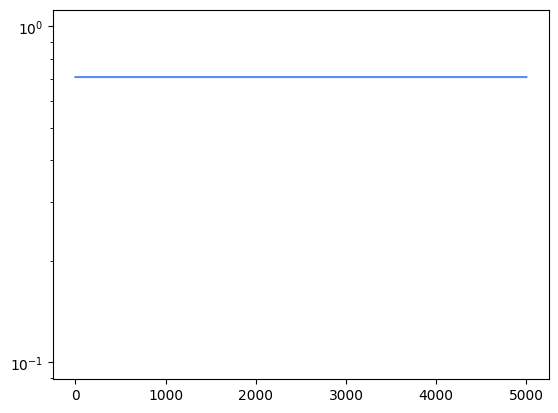

In [41]:
plt.semilogy(info.grad_norm)

In [25]:
from sdplab.special.qot import generate_random_qot, solve_qot_dual

In [26]:
qot, init_primal = generate_random_qot(d=4, N=2, proportions=(1., ))

/Users/pavlopelikh/Documents/Dev/SDPLab/.venv/lib/python3.13/site-packages/spacecore/_contextual/contextual.py:460: UserWarning: Converting from Context(ops=NumpyOps, dtype=dtype('complex128'), enable_checks=False) to Context(ops=JaxOps, dtype=dtype('complex128'), enable_checks=False).
  warn(


In [27]:
qot_p, qot_d = solve_qot_dual(qot, solver='SCS', verbose=True)

/Users/pavlopelikh/Documents/Dev/SDPLab/.venv/lib/python3.13/site-packages/spacecore/_contextual/contextual.py:460: UserWarning: Converting from Context(ops=JaxOps, dtype=dtype('complex128'), enable_checks=False) to Context(ops=NumpyOps, dtype=dtype('complex128'), enable_checks=True).
  warn(
(CVXPY) May 13 11:35:08 AM: Your problem has 32 variables, 256 constraints, and 0 parameters.
(CVXPY) May 13 11:35:08 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) May 13 11:35:08 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) May 13 11:35:08 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) May 13 11:35:08 AM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) May 13 11:35:08 AM: Compiling problem (target solver=SCS).
(CVXPY) May 13 11:35:08 AM: Reduction chain: Complex2Real -> FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> C

                                     CVXPY                                     
                                     v1.8.0                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 32, constraints m: 528
cones: 	  s: psd vars: 528, ssize: 1
settings: eps_abs: 1.0e-05, eps_rel: 1.0e-05, e

In [28]:
qot.primal_objective(init_primal)

Array(-1.68739952, dtype=float64)

In [29]:
qot.primal_objective(qot_p)

Array(-4.15717599, dtype=float64)

In [30]:
qot.A_apply(qot_p).val - qot.b

Array([[[-1.79459912e-06+6.53771253e-16j,
         -8.25190139e-07-7.74275302e-08j,
          6.95543586e-07+5.17004562e-07j,
          6.04945479e-08+3.09297104e-07j],
        [-8.25190139e-07+7.74275300e-08j,
         -1.00725123e-06+1.29693117e-15j,
          6.39322411e-07+1.71639699e-07j,
          5.28976043e-08+2.12043168e-08j],
        [ 6.95543586e-07-5.17004561e-07j,
          6.39322411e-07-1.71639700e-07j,
         -1.44361315e-06-6.48716993e-16j,
         -1.76175864e-07-2.89083837e-07j],
        [ 6.04945479e-08-3.09297106e-07j,
          5.28976043e-08-2.12043154e-08j,
         -1.76175864e-07+2.89083837e-07j,
         -7.18460955e-07+6.31299576e-16j]],

       [[-1.96386496e-06-4.45551606e-16j,
         -3.89192466e-07-2.22976111e-07j,
         -7.25746216e-07+1.80199479e-07j,
          1.35061797e-07+1.22222386e-06j],
        [-3.89192466e-07+2.22976111e-07j,
         -4.68133016e-07+1.29541140e-15j,
         -1.95947834e-07+2.17630438e-07j,
          4.52958441e-07+2.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

try:
    from IPython.display import display
except Exception:
    display = print

try:
    import qutip as qt
except Exception:
    qt = None

try:
    import jax
    import jax.numpy as jnp
    from spacecore import JaxOps
    jax.config.update("jax_enable_x64", True)
    HAS_JAX = True
except Exception:
    jax = None
    jnp = None
    JaxOps = None
    HAS_JAX = False

from spacecore import Context, NumpyOps
import seaborn as sns
sns.set_theme()

from sdplab.special.qot.barycenter import (
    GaussianPhaseSpace,
    GaussianState,
    QuadraticOperator,
    QuadraticOperatorTuple,
    QOTGaussianBarycenterProblem,
)

plt.rcParams.update({
    "figure.figsize": (7.0, 4.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

ctx = Context(NumpyOps(), dtype=np.float64)
print("QuTiP available:", qt is not None)
print("JAX available:", HAS_JAX)


QuTiP available: True
JAX available: True


In [3]:
space = GaussianPhaseSpace(1, ctx=ctx)
space

modes,1
dimension,2
coordinate order,"(Q1, P1, ..., Qm, Pm)"
tolerances,"atol=1e-09, rtol=1e-09"
backend,"numpy, dtype=float64, checks=True"


In [4]:
mean1 = mean2 = ctx.ops.zeros(2)
cov1 = ctx.asarray([
    [0.295916, 0.],
    [0., 4.866240],
])
cov2 = ctx.asarray([
    [0.536256, 0.],
    [0., 1.193460],
])


state1 = GaussianState(space, mean1, cov1, ctx=ctx)
state2 = GaussianState(space, mean2, cov2, ctx=ctx)

In [9]:
from sdplab.special.qot.barycenter._gaussian_calculus import _symplectic_eigvals_covariance

nu1 = _symplectic_eigvals_covariance(state1.space, state1.cov)
nu2 = _symplectic_eigvals_covariance(state2.space, state2.cov)

nu1, nu2

(array([1.19999928]), array([0.80000005]))